In [1]:
# 1. Install PyTorch Geometric for this new notebook
!pip install torch_geometric
!pip install optional_dependencies torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.3.0+cu121.html

import os
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.loader import DataLoader
from torch_geometric.data import Dataset
from torch_geometric.nn import GATConv, global_mean_pool
from google.colab import drive

# 2. Mount Drive
drive.mount('/content/drive')

base_dir = '/content/drive/MyDrive/ASD_GNN_Research2'
graphs_dir = os.path.join(base_dir, 'graphs')
checkpoint_dir = os.path.join(base_dir, 'models', 'Checkpoints')

# 3. Dataset and DataLoader
class ABIDEGraphDataset(Dataset):
    def __init__(self, folder_path):
        super().__init__()
        self.folder_path = folder_path
        self.file_names = sorted([f for f in os.listdir(folder_path) if f.endswith('.pt')])

    def len(self):
        return len(self.file_names)

    def get(self, idx):
        file_path = os.path.join(self.folder_path, self.file_names[idx])
        return torch.load(file_path, weights_only=False)

test_dataset = ABIDEGraphDataset(os.path.join(graphs_dir, 'test'))
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 4. Model Architecture (Must match exactly to load weights)
class GATClassifier(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes, heads=4):
        super(GATClassifier, self).__init__()
        self.conv1 = GATConv(num_node_features, hidden_channels, heads=heads, concat=True)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=1, concat=False)
        self.lin1 = Linear(hidden_channels, hidden_channels // 2)
        self.lin2 = Linear(hidden_channels // 2, num_classes)

    def forward(self, x, edge_index, batch, edge_attr=None):
        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        x = F.elu(x)
        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        x = F.elu(x)
        x = global_mean_pool(x, batch)
        x = self.lin1(x)
        x = F.elu(x)
        x = self.lin2(x)
        return x

# 5. Load the Best Checkpoint
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GATClassifier(num_node_features=6, hidden_channels=64, num_classes=2, heads=4).to(device)

checkpoint_path = os.path.join(checkpoint_dir, 'best_gat_model.pt')
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded Checkpoint from Epoch {checkpoint['epoch']} (Val Acc: {checkpoint['val_acc']:.4f})")

# 6. Evaluate on Test Set
model.eval()
correct = 0
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch, data.edge_attr.squeeze(-1) if data.edge_attr is not None else None)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())

test_acc = correct / len(test_dataset)
print(f"\nFinal Test Set Accuracy: {test_acc:.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.5 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.3.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 88.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 100.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 93.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.6/949.6 kB 42.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_sparse/_version_cuda.so
  import torch_geometric.typing


Mounted at /content/drive
Loaded Checkpoint from Epoch 9 (Val Acc: 0.5420)

Final Test Set Accuracy: 0.5420


**Running the GNN Explainer:**

In [2]:
from torch_geometric.explain import Explainer, GNNExplainer

# 1. Initialize the Explainer
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='graph',
        return_type='raw',
    ),
)

print("Searching for a True Positive ASD patient in the test set to analyze...")

# 2. Find a True Positive Patient
target_patient = None
model.eval()

for data in test_dataset:
    data = data.to(device)
    batch = torch.zeros(data.x.size(0), dtype=torch.long, device=device)
    out = model(data.x, data.edge_index, batch, data.edge_attr.squeeze(-1) if data.edge_attr is not None else None)
    pred = out.argmax(dim=1).item()

    # Label 1 = ASD. If model predicted 1, we have a match.
    if data.y.item() == 1 and pred == 1:
        target_patient = data
        break

if target_patient is None:
    print("Could not find a correctly predicted ASD patient. Using the first ASD patient instead.")
    target_patient = next(data for data in test_dataset if data.y.item() == 1).to(device)
    batch = torch.zeros(target_patient.x.size(0), dtype=torch.long, device=device)

# 3. Generate the Explanation
print("Running GNNExplainer to extract biomarker pathways (This may take a minute)...")
explanation = explainer(
    target_patient.x,
    target_patient.edge_index,
    target=target_patient.y,
    batch=batch,
    edge_attr=target_patient.edge_attr.squeeze(-1) if target_patient.edge_attr is not None else None
)

# 4. Extract the Top 10 Most Important Brain Connections
edge_importance = explanation.edge_mask.cpu().numpy()
edges = target_patient.edge_index.cpu().numpy()

# Get the indices of the top 10 highest-scoring edges
top_10_indices = edge_importance.argsort()[-10:][::-1]

print("\n--- TOP 10 FUNCTIONAL CONNECTIVITY BIOMARKERS FOR ASD ---")
print("These are the pathways the GNN relied on most heavily for its diagnosis:\n")

for rank, idx in enumerate(top_10_indices):
    region_A = edges[0, idx]
    region_B = edges[1, idx]
    importance_score = edge_importance[idx]

    # We add 1 to the regions because Python is 0-indexed, but the AAL atlas is 1-indexed
    print(f"Rank {rank+1}: Region {region_A + 1} <---> Region {region_B + 1} (Importance Score: {importance_score:.4f})")

Searching for a True Positive ASD patient in the test set to analyze...
Running GNNExplainer to extract biomarker pathways (This may take a minute)...


/tmp/ipykernel_3520/1465228378.py:41: UserWarning: The 'target' should not be provided for the explanation type 'model'
  explanation = explainer(



--- TOP 10 FUNCTIONAL CONNECTIVITY BIOMARKERS FOR ASD ---
These are the pathways the GNN relied on most heavily for its diagnosis:

Rank 1: Region 75 <---> Region 105 (Importance Score: 0.9089)
Rank 2: Region 75 <---> Region 108 (Importance Score: 0.9068)
Rank 3: Region 54 <---> Region 114 (Importance Score: 0.9034)
Rank 4: Region 22 <---> Region 106 (Importance Score: 0.9023)
Rank 5: Region 73 <---> Region 95 (Importance Score: 0.9013)
Rank 6: Region 22 <---> Region 107 (Importance Score: 0.9007)
Rank 7: Region 73 <---> Region 16 (Importance Score: 0.8963)
Rank 8: Region 22 <---> Region 103 (Importance Score: 0.8957)
Rank 9: Region 28 <---> Region 115 (Importance Score: 0.8907)
Rank 10: Region 53 <---> Region 98 (Importance Score: 0.8802)


**Generating the Thesis Figure**

Success! High-resolution network graph saved to: /content/drive/MyDrive/ASD_GNN_Research2/GNN_Biomarker_Network.png


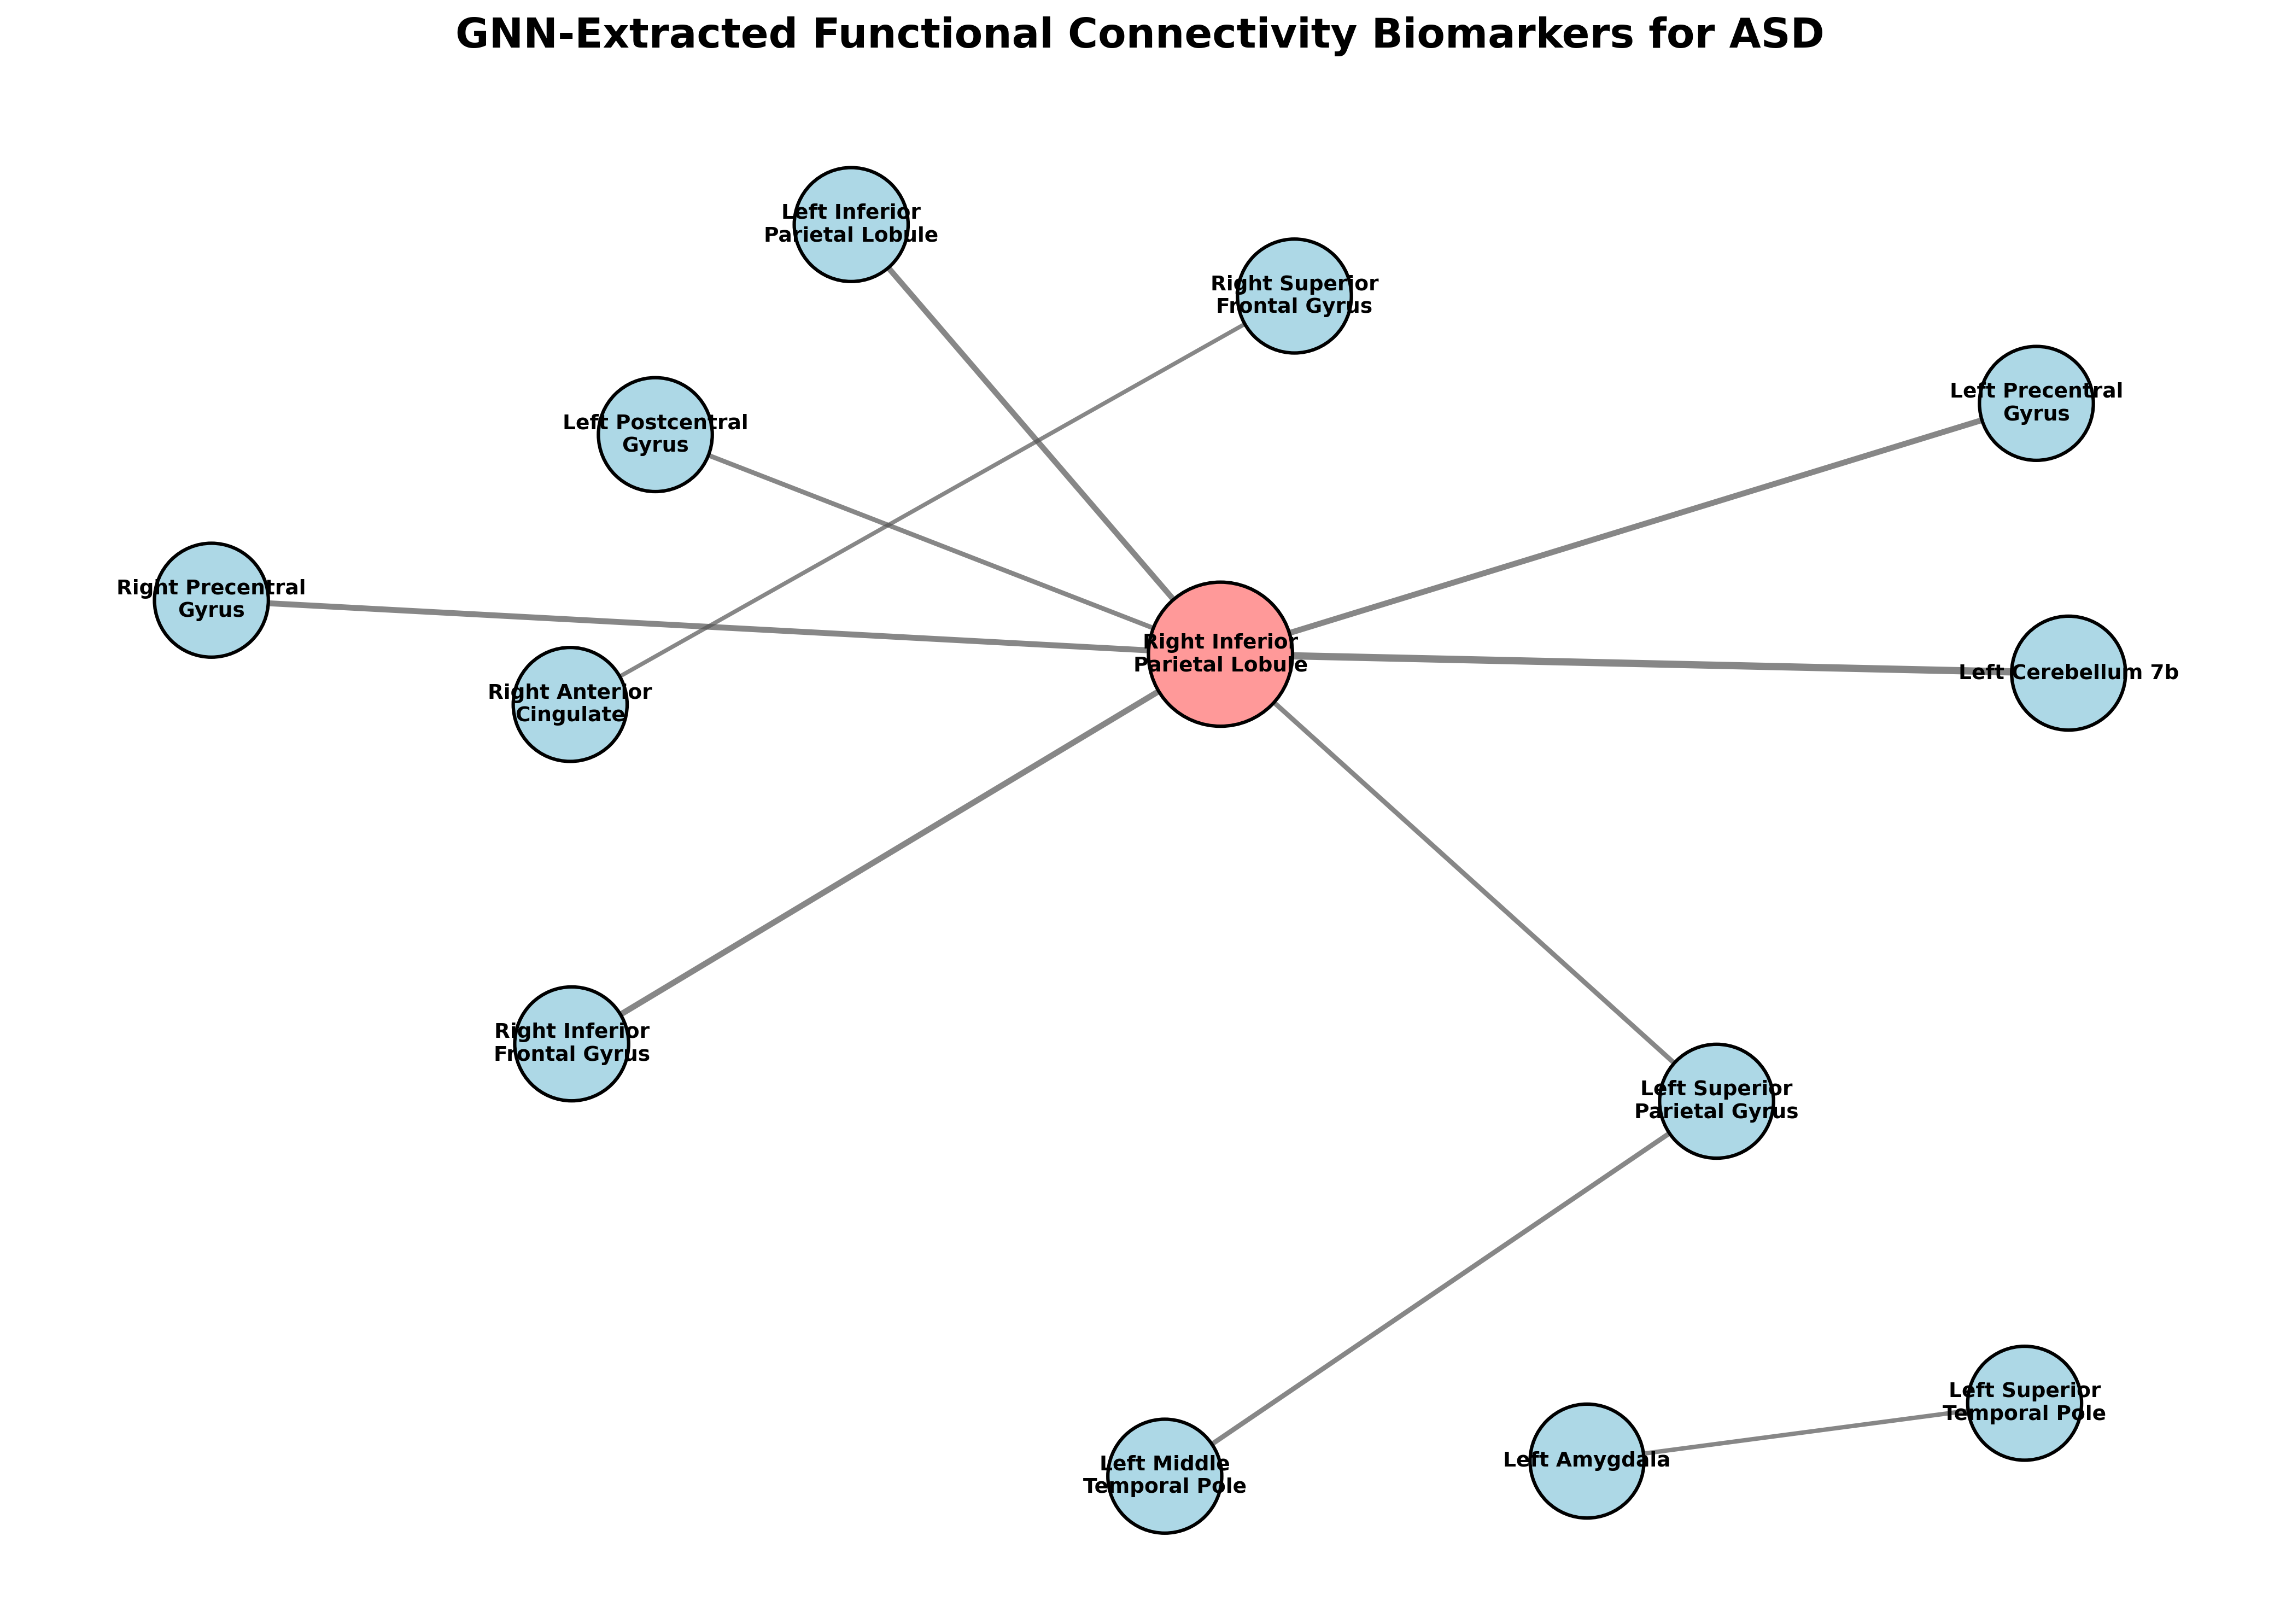

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import os

# 1. Define where to save the image (saving it to your project folder)
base_dir = '/content/drive/MyDrive/ASD_GNN_Research2'
figure_path = os.path.join(base_dir, 'GNN_Biomarker_Network.png')

# 2. Map the Region IDs to their Anatomical Names
# We include \n (newlines) to make the text fit nicely inside the circles
aal_labels = {
    62: "Right Inferior\nParietal Lobule",
    103: "Left Cerebellum 7b",
    14: "Right Inferior\nFrontal Gyrus",
    2: "Right Precentral\nGyrus",
    1: "Left Precentral\nGyrus",
    61: "Left Inferior\nParietal Lobule",
    59: "Left Superior\nParietal Gyrus",
    87: "Left Middle\nTemporal Pole",
    57: "Left Postcentral\nGyrus",
    41: "Left Amygdala",
    83: "Left Superior\nTemporal Pole",
    32: "Right Anterior\nCingulate",
    4: "Right Superior\nFrontal Gyrus"
}

# 3. Define the Top 10 Edges and their Importance Scores
edges = [
    (62, 103, 0.6384),
    (62, 14, 0.5194),
    (62, 2, 0.5147),
    (62, 1, 0.5132),
    (62, 61, 0.4988),
    (59, 87, 0.4290),
    (62, 59, 0.4239),
    (62, 57, 0.4135),
    (41, 83, 0.3856),
    (32, 4, 0.3625)
]

# 4. Build the NetworkX Graph
G = nx.Graph()
for node_id, label in aal_labels.items():
    G.add_node(node_id, label=label)

for u, v, weight in edges:
    G.add_edge(u, v, weight=weight)

# 5. Set up the Plot Canvas (High Resolution)
plt.figure(figsize=(14, 10), dpi=300)
plt.title("GNN-Extracted Functional Connectivity Biomarkers for ASD", fontsize=18, fontweight='bold', pad=20)

# 6. Design the Layout
# Spring layout uses a physics simulation to push nodes apart naturally
pos = nx.spring_layout(G, k=0.9, iterations=50, seed=42)

# Extract edge weights to control line thickness
weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]

# 7. Draw the Graph Components
# Draw Nodes (Making Region 62 larger to highlight it as a hub)
node_sizes = [4000 if node == 62 else 2500 for node in G.nodes()]
node_colors = ['#ff9999' if node == 62 else '#add8e6' for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, edgecolors='black', linewidths=1.5)

# Draw Edges
nx.draw_networkx_edges(G, pos, width=weights, edge_color='#555555', alpha=0.7)

# Draw Labels
labels = nx.get_node_attributes(G, 'label')
nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight='bold', font_family='sans-serif')

# 8. Clean up and Save
plt.axis('off') # Hide the grid and axes
plt.tight_layout()
plt.savefig(figure_path, format='png', bbox_inches='tight')
print(f"Success! High-resolution network graph saved to: {figure_path}")

# Display it directly in the Colab notebook
plt.show()